# Stochastic Events Set Generation
This notebook shows how to generate a stochastic event set from an [OQ Engine area source](https://github.com/gem/oq-engine/blob/master/openquake/hazardlib/source/area.py#L25) with known geometry (i.e. a polygon in a shapefile or geojson), a [magnitude-frequency distribution (MFD)](https://github.com/gem/oq-engine/tree/master/openquake/hazardlib/mfd), and a hypocentral depth distribution (optionally specified by means of an [OQ Engine probability mass function](https://github.com/gem/oq-engine/blob/master/openquake/hazardlib/pmf.py#L24)).

For a simple and straightforward SES generation, we develop a couple of functionalities in [openquake.man.ses_utils](https://github.com/GEMScienceTools/oq-mbtk/tree/master/openquake/man/ses_utils). If you prefer to perform full SES generation, you might follow the event-based PSHA calculation described in the [Seismic Source Module](https://gemsciencetools.github.io/quakeT/contents/ssc.html).

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from openquake.man.ses_utils.ses_generator import ses_from_area_source
from openquake.hazardlib.pmf import PMF
from openquake.hazardlib.mfd import TruncatedGRMFD

To generate SES with this workflow, first you need to determine which MFD you will use. Here, we prefer to use `TruncatedGRMFD` to show another MFD than previously showed one in the [first notebook](https://gemsciencetools.github.io/quakeT/contents/mfd_calculation.html).

This distribution is described by means of a minimum `minMag` and maximum magnitude `maxMag` and by the  $a-$ and $b-$values of the Gutenberg-Richter relationship.

In [2]:
magnitude_step = 0.2
magnitudes = np.arange(4.1, 7.0, magnitude_step)
rates = np.random.rand(magnitudes.size)
mfd = TruncatedGRMFD(4.0, 7.0, 0.1, 4.5, 1.0) # min_mag, max_mag, bin_width, a_val, b_val

The figure below shows the MFD obtained using the parameters of the considered example.

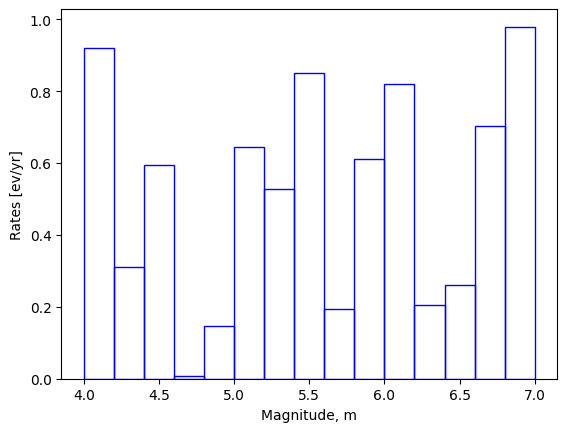

In [3]:
_ = plt.bar(magnitudes, rates, width=magnitude_step, fc='none', ec='blue')
_ = plt.xlabel('Magnitude, m')
_ = plt.ylabel('Rates [ev/yr]')

You can use `ses_from_area_source` utility to produce 1000 years SES by sampling earthquake ruptures from configured seismic sources using Monte Carlo sampling [[16]](references.html#ref-musson-1999). 

Apart from MFD, you need to define:
- an area source as a polygon file described in the [Data Format section](../../contents/data_formats.html),
- `hdd` which is an instance of :class:`openquake.hazardlib.pmf.PMF` describing the hypocentral depth distribution.

In [5]:
# Create the stochastic event set, i.e. a set of ruptures
fname = "../data/poly.geojson"
hdd = PMF([(0.3, 5.0), (0.7, 10.0)])
ses = ses_from_area_source(fname, mfd, hdd)

In [6]:
df_data = []
for r in ses:
    real_rupture = r.rupture
    hypo = real_rupture.hypocenter
    
    df_data.append({
        "rupture_id": r.id,
        "magnitude": r.mag,
        "longitude": hypo.longitude,
        "latitude": hypo.latitude,
        "depth": hypo.depth,
        "tectonic_region": r.tectonic_region_type
    })

df_ses = pd.DataFrame(df_data)
df_ses.head(10)

#Save
output_dir = "../output/ses_generation"
os.makedirs(output_dir, exist_ok=True)
csv_file_path = os.path.join(output_dir, "stochastic_event_set.csv")
df_ses.to_csv(csv_file_path, index=False)
print(f"Done! Saved to: {csv_file_path}")

Done! Saved to: ../output/ses_generation/stochastic_event_set.csv
